In [17]:
import numpy as np
import pandas as pd
import os.path as op
import matplotlib.pyplot as plt
from glob import glob
from scipy import stats, io

In [7]:
data_folder = "/shares/zne.uzh/multlearn/bestFittingVals"

In [51]:
def get_parameters(subject, bestfitting_path):
    rpe_path = (
            op.join(bestfitting_path,f"sub-{subject}/rpe*.mat")
        )
    fn = glob(rpe_path)
    
    assert len(fn) == 1
    fn = fn[0]

    rpe_data = np.nan_to_num(
        io.loadmat(fn)["rpe"]
    )

    rpe = (
        pd.DataFrame(
            rpe_data,
            index=pd.Index(np.arange(1, 6 + 1), name="run"),
            columns=pd.Index(np.arange(1, 60 + 1), name="trial_nr"),
        )
        .stack()
        .to_frame("rpe")
    )

    surprise_path = (
        op.join(bestfitting_path,f"sub-{subject}/spe*.mat")
    )
    fn2 = glob(surprise_path)
    assert len(fn2) == 1
    fn2 = fn2[0]
    surprise_data = np.nan_to_num(
        io.loadmat(fn2)["spe"]
    )
    surprise = (
        pd.DataFrame(
            surprise_data,
            index=pd.Index(np.arange(1, 6 + 1), name="run"),
            columns=pd.Index(np.arange(1, 60 + 1), name="trial_nr"),
        )
        .stack()
        .to_frame("spe")
    )

    V0_path = (
        op.join(bestfitting_path,f"sub-{subject}/V0*.npy")
    )
    fn3 = glob(V0_path)
    assert len(fn3) == 1
    fn3 = fn3[0]
    V0_data = np.nan_to_num(np.load(fn3))

    V0 = (
        pd.DataFrame(
            V0_data,
            index=pd.Index(np.arange(1, 6 + 1), name="run"),
            columns=pd.Index(np.arange(1, 60 + 1), name="trial_nr"),
        )
        .stack()
        .to_frame("V0")
    )

    V1_path = (
        op.join(bestfitting_path,f"sub-{subject}/V1*.npy")
    )
    fn4 = glob(V1_path)
    assert len(fn4) == 1
    fn4 = fn4[0]
    V1_data = np.nan_to_num(np.load(fn4))

    V1 = (
        pd.DataFrame(
            V1_data,
            index=pd.Index(np.arange(1, 6 + 1), name="run"),
            columns=pd.Index(np.arange(1, 60 + 1), name="trial_nr"),
        )
        .stack()
        .to_frame("V1")
    )

    return rpe, surprise, V0, V1

In [52]:
sub01_rpe, sub01_surprise, sub01_V0, sub01_V1 = get_parameters("01",data_folder)

array([[<Axes: title={'center': 'rpe'}>]], dtype=object)

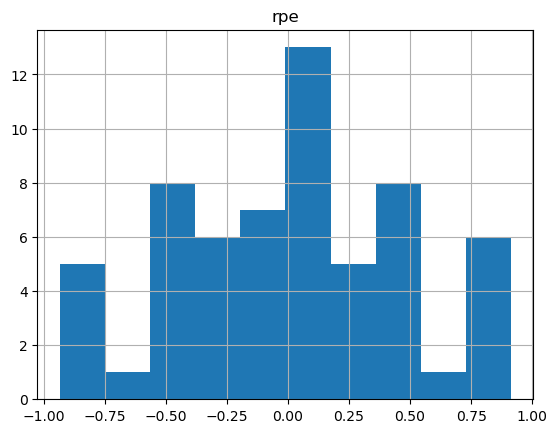

In [47]:
sub01_rpe[:60].hist("rpe")

array([[<Axes: title={'center': 'V1'}>]], dtype=object)

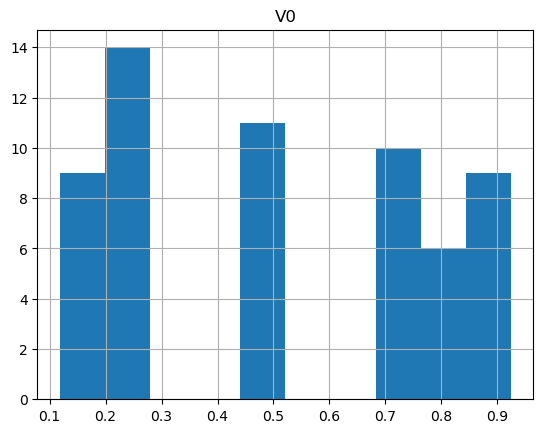

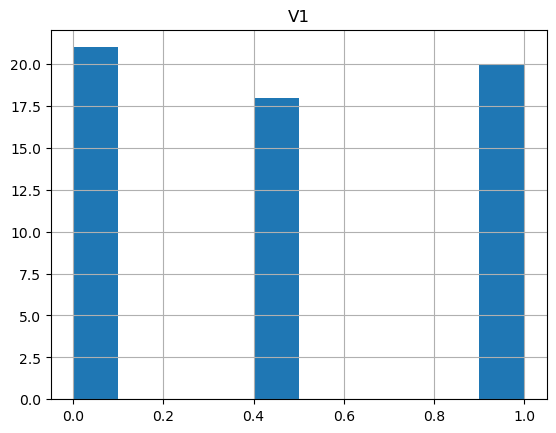

In [53]:
sub01_V0[61:120].hist("V0")
sub01_V1[61:120].hist("V1")

array([[<Axes: title={'center': 'spe'}>]], dtype=object)

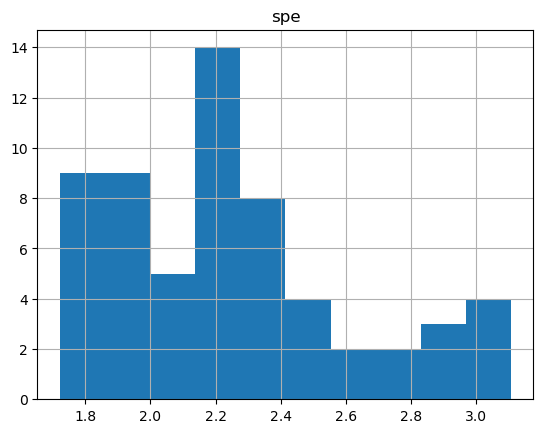

In [49]:
sub01_surprise[].hist("spe")

array([[<Axes: title={'center': 'spe'}>]], dtype=object)

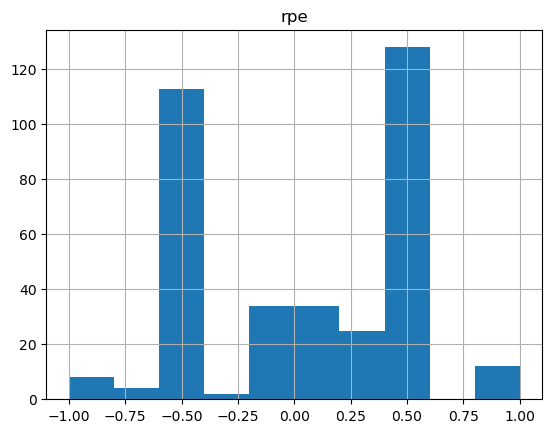

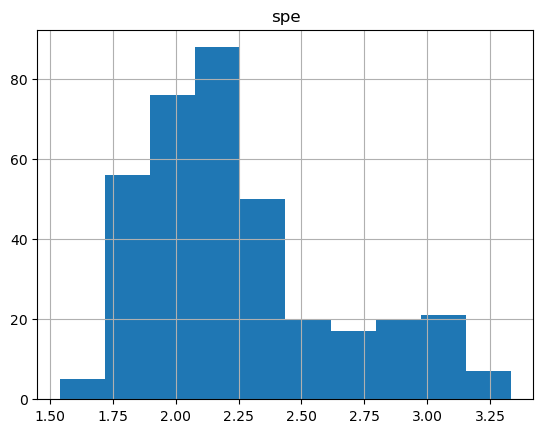

In [33]:
sub21_rpe, sub21_surprise = get_parameters("21",data_folder)
sub21_rpe.hist("rpe")
sub21_surprise.hist("spe")

array([[<Axes: title={'center': 'spe'}>]], dtype=object)

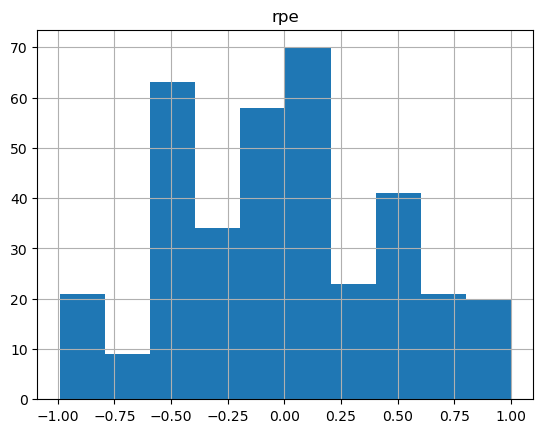

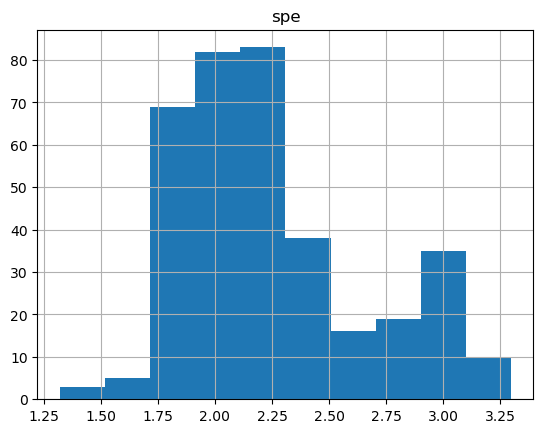

In [34]:
sub35_rpe, sub35_surprise = get_parameters("35",data_folder)
sub35_rpe.hist("rpe")
sub35_surprise.hist("spe")